In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

In [3]:
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)

In [5]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [6]:
df.shape

(20640, 8)

In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
data.target.shape

(20640,)

In [9]:
# df = df.sample(frac=0.20)
#to visualise the tree, selecting only 20 percent of the data, feel free to comment this line to train the model

In [10]:
df.shape

(20640, 8)

In [11]:
#separate independent variable(X) and dependent variable(y)

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [12]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85
...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43


In [13]:
y

,Longitude
0,-122.23
1,-122.22
2,-122.24
3,-122.25
4,-122.25
...,...
20635,-121.09
20636,-121.21
20637,-121.22
20638,-121.32


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.3, random_state= 1)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((14448, 7), (6192, 7), (14448,), (6192,))

In [16]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model

DecisionTreeRegressor()

In [17]:
model.fit(X_train, y_train)

DecisionTreeRegressor()

In [18]:
y_pred = model.predict(X_test)

In [19]:
y_pred

array([-118.4 , -119.75, -122.5 , ..., -122.24, -121.29, -118.29])

In [20]:
y_pred.shape

(6192,)

In [48]:
from sklearn.metrics import r2_score
r2_score(y_pred, y_test)

0.89017092407979

In [34]:
#hyperparameter tuning

parameter = {
    'criterion': ['squared_error','absolute_error', 'friedman_mse', 'poisson'],
    'splitter': ['best', 'random'],
    'max_depth': [1,2,3,4,5,10],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [35]:
regressor = DecisionTreeRegressor()

In [36]:
from sklearn.model_selection import GridSearchCV
model = GridSearchCV(regressor, param_grid= parameter, cv= 3, scoring= 'neg_mean_squared_error', verbose=3)
model

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error', verbose=3)

In [37]:
model.fit(X_train, y_train)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
[CV 1/3] END criterion=squared_error, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 2/3] END criterion=squared_error, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 3/3] END criterion=squared_error, max_depth=1, max_features=auto, splitter=best;, score=nan total time=   0.0s
[CV 1/3] END criterion=squared_error, max_depth=1, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 2/3] END criterion=squared_error, max_depth=1, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 3/3] END criterion=squared_error, max_depth=1, max_features=auto, splitter=random;, score=nan total time=   0.0s
[CV 1/3] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-3.974 total time=   0.0s
[CV 2/3] END criterion=squared_error, max_depth=1, max_features=sqrt, splitter=best;, score=-0.696 total time=   0.0s
[CV 3

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'absolute_error',
                                       'friedman_mse', 'poisson'],
                         'max_depth': [1, 2, 3, 4, 5, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error', verbose=3)

In [38]:
model.best_params_

{'criterion': 'friedman_mse',
 'max_depth': 10,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [39]:
final_model = DecisionTreeRegressor(criterion= 'friedman_mse', max_depth= 10, max_features= 'sqrt', splitter= 'best')
final_model

DecisionTreeRegressor(criterion='friedman_mse', max_depth=10,
                      max_features='sqrt')

In [40]:
final_model.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=10,
                      max_features='sqrt')

[Text(0.5736720419337606, 0.9545454545454546, 'x[1] <= 49.5\nfriedman_mse = 4.027\nsamples = 14448\nvalue = -119.571'),
 Text(0.3067992120726496, 0.8636363636363636, 'x[2] <= 4.263\nfriedman_mse = 3.909\nsamples = 13451\nvalue = -119.478'),
 Text(0.4402356270032051, 0.9090909090909092, 'True  '),
 Text(0.1367855235042735, 0.7727272727272727, 'x[6] <= 36.41\nfriedman_mse = 2.911\nsamples = 2654\nvalue = -118.973'),
 Text(0.0633346688034188, 0.6818181818181818, 'x[1] <= 24.5\nfriedman_mse = 0.422\nsamples = 2019\nvalue = -118.097'),
 Text(0.031850961538461536, 0.5909090909090909, 'x[6] <= 33.715\nfriedman_mse = 0.673\nsamples = 620\nvalue = -117.958'),
 Text(0.015892094017094016, 0.5, 'x[6] <= 33.55\nfriedman_mse = 0.281\nsamples = 196\nvalue = -117.118'),
 Text(0.006677350427350427, 0.4090909090909091, 'x[3] <= 0.925\nfriedman_mse = 0.183\nsamples = 157\nvalue = -117.007'),
 Text(0.003205128205128205, 0.3181818181818182, 'x[4] <= 885.0\nfriedman_mse = 0.548\nsamples = 3\nvalue = -116.04

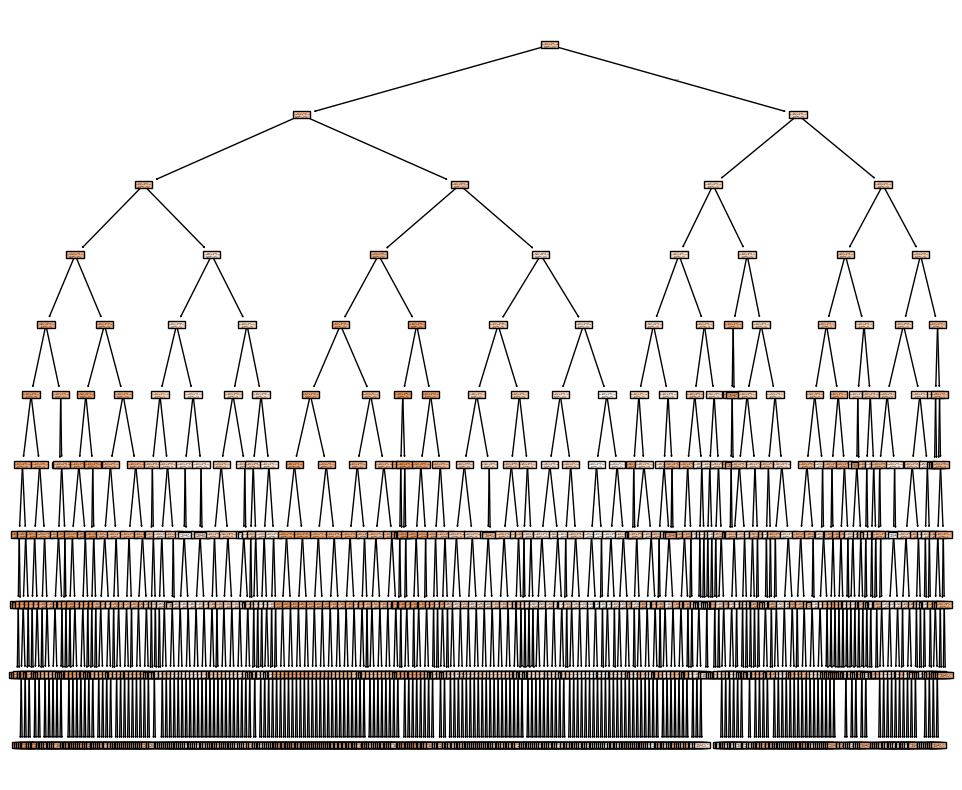

In [44]:
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(final_model, filled= True)

In [45]:
y_pred = final_model.predict(X_test)

In [47]:
r2_score(y_pred, y_test)

0.89017092407979